In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
# Load csv file

df = pd.read_csv('Boston-house-price-data.csv')

In [9]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
# check columns

df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [10]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [12]:
# look for any Nulls

df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [13]:
corr = df.corr()

<Axes: >

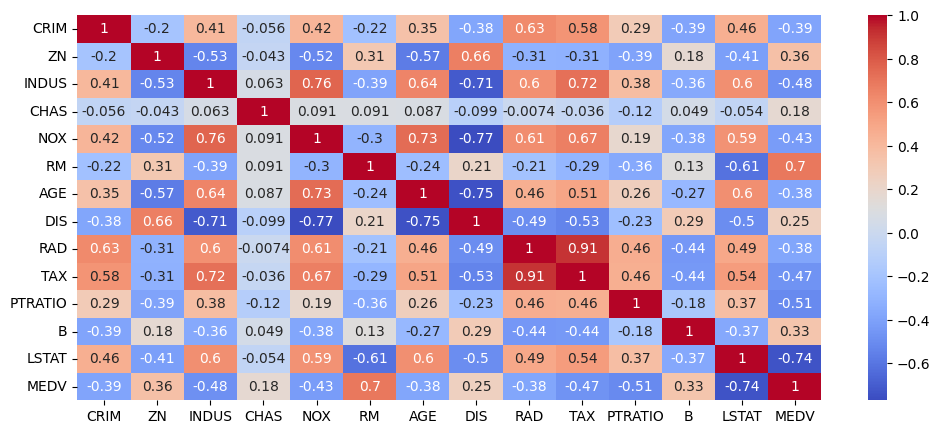

In [14]:
plt.figure (figsize = (12,5))

sns.heatmap(corr, 
            annot = True,
            cmap = "coolwarm"
           )

### Observation: Correlation Heatmap

* A correlation heatmap was plotted to understand the relationship between the independent variables and the target variable (**MEDV**), as well as the relationships among the independent variables.
* The target variable **MEDV** showed a **strong positive correlation** with **RM**, indicating that houses with more rooms tend to have higher prices.
* **LSTAT** exhibited a **strong negative correlation** with **MEDV**, suggesting that an increase in the percentage of lower-status population is associated with lower house prices.
* Features such as **PTRATIO**, **TAX**, **INDUS**, and **NOX** also showed moderate negative correlations with the target variable.
* A strong positive correlation was observed between **RAD** and **TAX**, indicating potential multicollinearity among the predictor variables.
* Since the heatmap only shows **pairwise correlations**, Variance Inflation Factor (VIF) analysis was performed to further evaluate multicollinearity among all independent variables.
* The heatmap provided valuable insights into feature relationships and guided further regression analysis.


In [15]:
corr['MEDV'].sort_values(ascending = False)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

### Summary

* The correlation of each feature with the target variable (**MEDV**) was analyzed to identify the most influential predictors.
* **RM** showed the strongest positive correlation with house prices, indicating that houses with more rooms tend to have higher prices.
* **LSTAT** exhibited the strongest negative correlation, suggesting that higher values of LSTAT are associated with lower house prices.
* Several other features, including **PTRATIO**, **TAX**, **INDUS**, and **NOX**, also showed moderate negative correlations with the target variable.
* This analysis helped in understanding feature importance and served as a preliminary step before building the Multiple Linear Regression model.
* Since correlation only measures pairwise relationships, a **VIF analysis** was performed later to evaluate multicollinearity among the predictor variables.


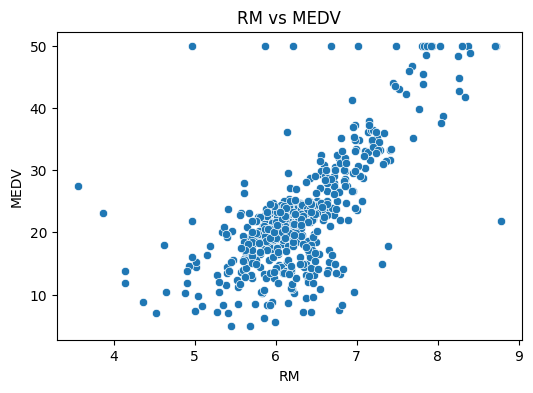

In [16]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df["RM"],
    y=df["MEDV"]
)

plt.title("RM vs MEDV")
plt.show()

### Observation

The scatter plot between **RM** (average number of rooms) and **MEDV** (median house value) shows a clear positive linear relationship. As the average number of rooms increases, the median house price also tends to increase. This indicates that **RM** is an important predictor of house prices and is likely to contribute significantly to the Multiple Linear Regression model.


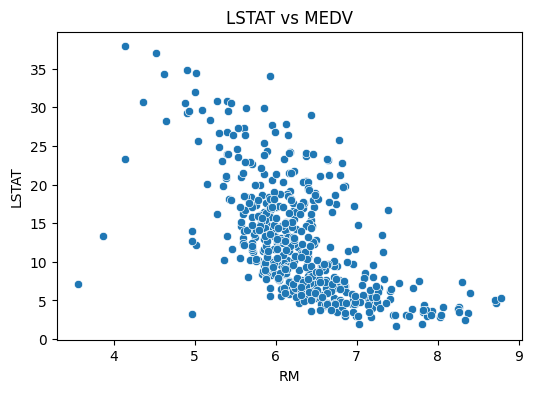

In [17]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df["RM"],
    y=df["LSTAT"]
)

plt.title("LSTAT vs MEDV")
plt.show()

### Observation

The scatter plot between **RM** (average number of rooms) and **LSTAT** (percentage of lower-status population) shows a clear negative relationship. As the average number of rooms increases, the percentage of the lower-status population tends to decrease. This inverse relationship indicates that neighborhoods with larger houses generally have lower LSTAT values, suggesting a strong association between these two predictor variables.


In [18]:
# Defining Independant & Dependant features

x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [19]:
x

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [20]:
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64

In [21]:
# train test split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.33, random_state = 42)

In [22]:
# Scaling down the features into similar scale/range

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)




In [23]:
# Applying LinearRegression

from sklearn.linear_model import LinearRegression

regression = LinearRegression()

regression.fit(x_train_scaled, y_train)

LinearRegression()

In [24]:
regression.coef_

array([-0.98858032,  0.86793276,  0.40502822,  0.86183791, -1.90009974,
        2.80813518, -0.35866856, -3.04553498,  2.03276074, -1.36400909,
       -2.0825356 ,  1.04125684, -3.92628626])

The regression coefficients indicate the direction and relative influence of each predictor on the target variable. Positive coefficients (RM, RAD, B, ZN, and CHAS) increase the predicted house price, while negative coefficients (LSTAT, DIS, PTRATIO, NOX, TAX, AGE, and CRIM) decrease it. Among all predictors, LSTAT has the strongest negative influence, whereas RM has one of the strongest positive influences on house prices. Since the input features were standardized before training, the coefficient magnitudes can be directly compared to assess their relative importance in the model.

In [25]:
regression.intercept_

np.float64(22.970796460176988)

The intercept represents the baseline prediction of the model when all standardized predictor variables are equal to zero (their mean values after scaling). It serves as the starting point of the regression equation, while the coefficients adjust the predicted house price based on the contribution of each feature.

Note: If you had not scaled the features, the intercept would represent the predicted house price when every predictor variable is exactly zero, which is often not meaningful for real-world data. Scaling makes the intercept easier to interpret because zero corresponds to the average value of each feature.

In [26]:
y_pred = regression.predict(x_test_scaled)

y_pred

array([28.53469469, 36.6187006 , 15.63751079, 25.5014496 , 18.7096734 ,
       23.16471591, 17.31011035, 14.07736367, 23.01064388, 20.54223482,
       24.91632351, 18.41098052, -6.52079687, 21.83372604, 19.14903064,
       26.0587322 , 20.30232625,  5.74943567, 40.33137811, 17.45791446,
       27.47486665, 30.2170757 , 10.80555625, 23.87721728, 17.99492211,
       16.02608791, 23.268288  , 14.36825207, 22.38116971, 19.3092068 ,
       22.17284576, 25.05925441, 25.13780726, 18.46730198, 16.60405712,
       17.46564046, 30.71367733, 20.05106788, 23.9897768 , 24.94322408,
       13.97945355, 31.64706967, 42.48057206, 17.70042814, 26.92507869,
       17.15897719, 13.68918087, 26.14924245, 20.2782306 , 29.99003492,
       21.21260347, 34.03649185, 15.41837553, 25.95781061, 39.13897274,
       22.96118424, 18.80310558, 33.07865362, 24.74384155, 12.83640958,
       22.41963398, 30.64804979, 31.59567111, 16.34088197, 20.9504304 ,
       16.70145875, 20.23215646, 26.1437865 , 31.12160889, 11.89

In [27]:
# evaluation metrics

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

mae =  mean_absolute_error(y_pred, y_test)
mse = mean_squared_error(y_pred, y_test)
score = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print(rmse)

print("MAE:",mae)
print("MSE:", mse)
print("R2_Score:", score)

4.552364598463062
MAE: 3.148255754816832
MSE: 20.724023437339753
R2_Score: 0.7261570836552476


In [28]:
# Adjusted R2

1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test_scaled.shape[1]-1)

0.7028893848808568

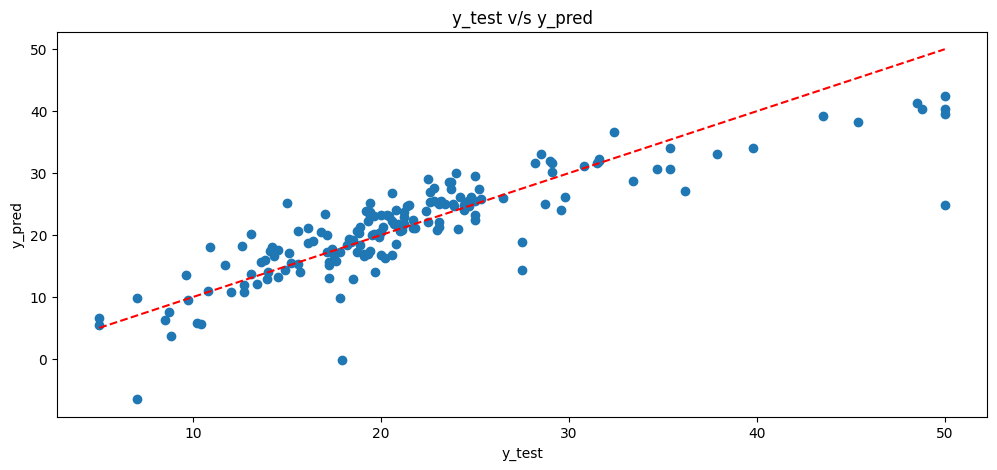

In [56]:
plt.figure(figsize = (12,5))

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--'
)
plt.title("y_test v/s y_pred")
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.show()

### Observation

The scatter plot comparing the actual house prices (`y_test`) and the predicted house prices (`y_pred`) shows that most data points lie close to the 45-degree reference line. This indicates that the model's predictions closely match the actual values for a majority of the observations. While a few points deviate from the reference line, suggesting some prediction errors, the overall alignment demonstrates that the Multiple Linear Regression model has learned the underlying relationship reasonably well and provides satisfactory predictive performance.


<Axes: xlabel='MEDV', ylabel='Count'>

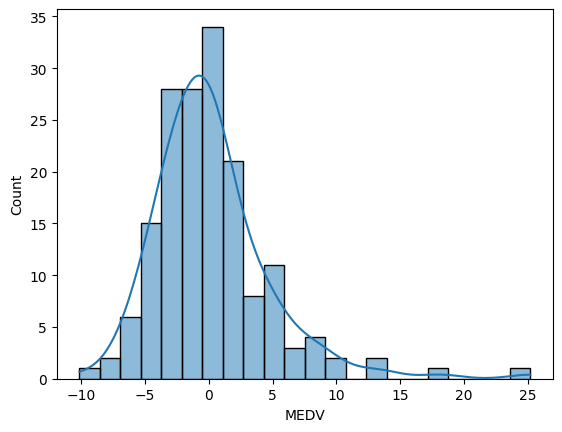

In [29]:
residuals = y_test-y_pred

sns.histplot(residuals, kde = True)

The histogram of the residuals shows that the prediction errors are approximately normally distributed and centered around zero. The distribution resembles a bell-shaped curve with only a slight skew, indicating that the model does not exhibit significant systematic bias. This suggests that the normality assumption of Multiple Linear Regression is reasonably satisfied, supporting the reliability of the model's predictions.

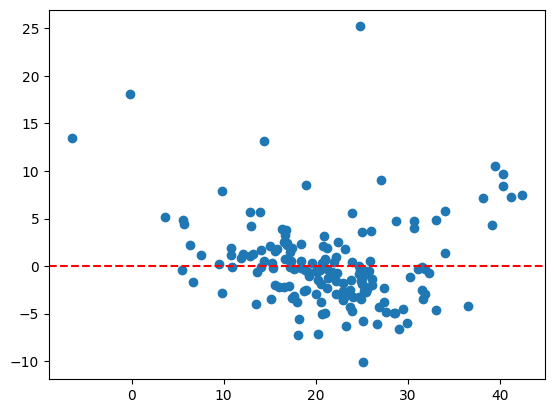

In [30]:
plt.scatter( y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')


The residuals vs predicted values plot shows that the residuals are randomly scattered around the zero reference line without any clear pattern or systematic trend. This random distribution indicates that the model's errors have approximately constant variance (homoscedasticity) and that the linearity assumption is reasonably satisfied. Although a few observations exhibit larger residuals, there is no evidence of a funnel-shaped pattern or curvature, suggesting that the Multiple Linear Regression model fits the data appropriately

### Observation - Multiple Linear Regression

* The Multiple Linear Regression model achieved an R² score of **72.58%**.
* Residual analysis showed that the residuals were approximately normally distributed and centered around zero.
* The residual vs predicted plot exhibited a mostly random scatter pattern, indicating that the assumptions of linearity and homoscedasticity were reasonably satisfied.
* VIF analysis revealed the presence of multicollinearity among several predictor variables.
* Despite the multicollinearity, the model demonstrated good predictive performance and was selected as the baseline model.


In [31]:
!pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create VIF dataframe
vif = pd.DataFrame()

# Feature names
vif["Feature"] = x.columns

# Calculate VIF for each feature
vif["VIF"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]

# Sort by highest VIF
vif = vif.sort_values(by="VIF", ascending=False)

print(vif)

    Feature        VIF
10  PTRATIO  85.029547
5        RM  77.948283
4       NOX  73.894947
9       TAX  61.227274
6       AGE  21.386850
11        B  20.104943
8       RAD  15.167725
7       DIS  14.699652
2     INDUS  14.485758
12    LSTAT  11.102025
1        ZN   2.844013
0      CRIM   2.100373
3      CHAS   1.152952


### Observation: Multicollinearity Check Using VIF

* Variance Inflation Factor (VIF) was calculated to detect multicollinearity among the independent variables.
* Several features such as **PTRATIO, RM, NOX, TAX, AGE, B, RAD, DIS, INDUS, and LSTAT** exhibited VIF values greater than 10, indicating significant multicollinearity.
* Features **ZN, CRIM, and CHAS** showed low VIF values, suggesting minimal correlation with other predictors.
* The presence of high multicollinearity may lead to unstable coefficient estimates and reduced interpretability of the model.
* Despite the high VIF values, the Multiple Linear Regression model achieved an **R² score of approximately 72.6%**, indicating reasonable predictive performance.
* To address multicollinearity, regularization techniques such as **Ridge Regression, Lasso Regression, and Elastic Net** can be evaluated and compared with the baseline Linear Regression model.


# Ridge Regression

In [49]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha = 1.0)

ridge.fit(x_train_scaled, y_train)

y_pred_ridge = ridge.predict(x_test_scaled)


In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2:", r2_score(y_test, y_pred_ridge))

MAE: 3.1460114626616926
MSE: 20.752416320800297
R2: 0.725781906024621


# Lasso Regression

In [51]:
from sklearn.linear_model import Lasso
Lasso = Lasso(alpha = 1.0)

Lasso.fit(x_train_scaled, y_train)

y_pred_lasso = Lasso.predict(x_test_scaled)


In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2:", r2_score(y_test, y_pred_lasso))

MAE: 3.6464026430077423
MSE: 26.16637721498099
R2: 0.6542429577734992


# Elastic Net

In [54]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha = 0.1 , l1_ratio = 0.5)

elastic.fit(x_train_scaled, y_train)

y_pred_elastic = elastic.predict(x_test_scaled)

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred_elastic ))
print("MSE:", mean_squared_error(y_test, y_pred_elastic ))
print("R2:", r2_score(y_test, y_pred_elastic ))

MAE: 3.1490655150441023
MSE: 21.614784874267837
R2: 0.7143867481123758


In [56]:
results = pd.DataFrame({
    "Model":["Linear Regression","Ridge","Lasso","ElasticNet"],
    "R2":[
        r2_score(y_test,y_pred),
        r2_score(y_test,y_pred_ridge),
        r2_score(y_test,y_pred_lasso),
        r2_score(y_test,y_pred_elastic)
    ]
})

results

,Model,R2
0,Linear Regression,0.725782
1,Ridge,0.725782
2,Lasso,0.654243
3,ElasticNet,0.714387


Among all the evaluated models, Multiple Linear Regression and Ridge Regression achieved the highest R² score of 72.58%. Since Ridge Regression did not provide any improvement over the baseline model, Multiple Linear Regression was selected as the final model for predicting house prices in the Boston Housing dataset.

In [57]:
new_house = [[
    0.1,    # CRIM
    20,     # ZN
    5.0,    # INDUS
    0,      # CHAS
    0.5,    # NOX
    6.5,    # RM
    50,     # AGE
    4.0,    # DIS
    4,      # RAD
    300,    # TAX
    15,     # PTRATIO
    390,    # B
    10      # LSTAT
]]

new_house_scaled = scaler.transform(new_house)
prediction = regression.predict(new_house_scaled)

print("Predicted House Price:", prediction[0])

Predicted House Price: 28.975670574108577


C:\Users\mohan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
